In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPRegressor, MLPClassifier
import sklearn.metrics
import matplotlib.pyplot as plt

from ct_foundation_brain.locations import data_dir, src_data_dir

In [2]:
df_labels = pd.read_csv(os.path.join(src_data_dir, 'bhsd_2023_ct_herrmohage/label_192/ground_truths.csv'))
input_data = np.load(os.path.join(data_dir, 'bhsd/embeddings/origin/embeddings_final.npz'), allow_pickle=True)
df_embeddings = pd.DataFrame(
    {
        'filename': input_data['filename'],
        'embedding': list(input_data['embedding'])
    }
)

df_embeddings = df_embeddings.merge(df_labels, on='filename', how='inner')
df_embeddings = df_embeddings.sample(frac=1, random_state=0).reset_index(drop=True)

In [9]:
ntrain = int(len(df_embeddings) * 0.8)
ntest = len(df_embeddings) - ntrain
df_train = df_embeddings.iloc[:ntrain]
df_test = df_embeddings.iloc[ntrain:]

Positive rate 0.3202614379084967 0.28205128205128205
RMSE_train: 0.5289965666997543
RMSE: 30.37443654451677
Accuracy_train: 1.0
Accuracy: 0.4358974358974359
Accuracy_train_binary: 1.0
Accuracy_binary: 0.5641025641025641
AUC: 0.6363636363636364


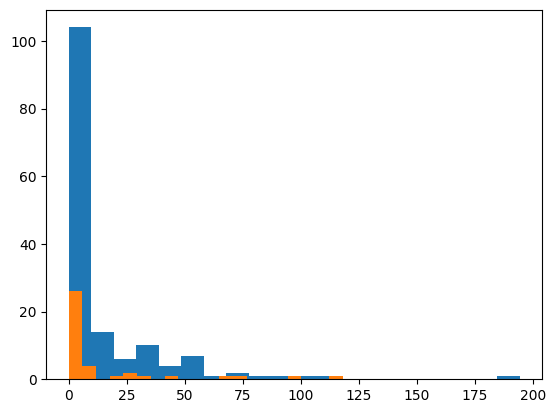

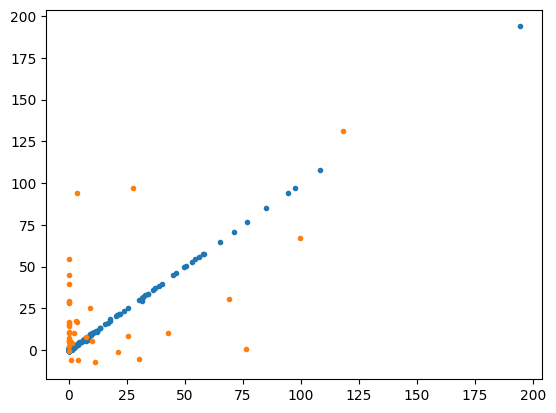

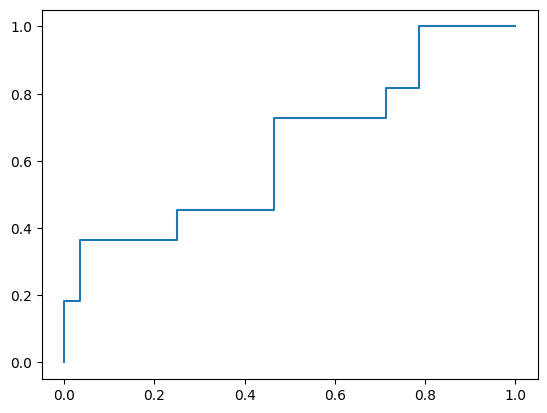

In [21]:
# build an ensemble tree on label
ilabel = 2
vol_th = 10

x_train = np.array(df_train['embedding'].tolist())
y_train = df_train[f'label_{ilabel}_cm3']
y_train_binary = y_train > vol_th
x_test = np.array(df_test['embedding'].tolist())
y_test = df_test[f'label_{ilabel}_cm3']
y_test_binary = y_test > vol_th

plt.figure()
plt.hist(y_train, bins=20)
plt.hist(y_test, bins=20)

print('Positive rate', np.mean(y_train_binary), np.mean(y_test_binary))

reg = MLPRegressor(hidden_layer_sizes=(128, 16), max_iter=500, random_state=0)
reg.fit(x_train, y_train)
y_pred_train = reg.predict(x_train)
y_pred = reg.predict(x_test)
print('RMSE_train:', np.sqrt(np.mean((y_pred_train - y_train) ** 2)))
print('RMSE:', np.sqrt(np.mean((y_pred - y_test) ** 2)))
y_pred_train_th = y_pred_train > vol_th
y_train_th = y_train > vol_th
y_pred_th = y_pred > vol_th
y_test_th = y_test > vol_th
print('Accuracy_train:', np.mean(y_pred_train_th == y_train_th))
print('Accuracy:', np.mean(y_pred_th == y_test_th))

plt.figure()
plt.plot(y_train, y_pred_train, '.')
plt.plot(y_test, y_pred, '.')

clf = MLPClassifier(hidden_layer_sizes=(128, 32), max_iter=500, random_state=0)
clf.fit(x_train, y_train_binary)
y_pred_train_binary = clf.predict(x_train)
y_pred_binary = clf.predict(x_test)
y_pred_prob = clf.predict_proba(x_test)[:, 1]
print('Accuracy_train_binary:', np.mean(y_pred_train_binary == y_train_binary))
print('Accuracy_binary:', np.mean(y_pred_binary == y_test_binary))
auc = sklearn.metrics.roc_auc_score(y_test_binary, y_pred_prob)
print('AUC:', auc)
# roc curve
fpr, tpr, _ = sklearn.metrics.roc_curve(y_test_binary, y_pred_prob)
plt.figure()
plt.plot(fpr, tpr)

In [15]:
import tensorflow as tf

os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

def create_model(heads,
                 token_num=1,
                 embeddings_size=1408,
                 learning_rate=0.07,
                 end_lr_factor=1.0,
                 dropout=0.5,
                 loss_weights=None,
                 hidden_layer_sizes=[128, 32],
                 weight_decay=0.0001,
                 seed=None) -> tf.keras.Model:
  """
  Creates linear probe or multilayer perceptron using LARS.

  """
  inputs = tf.keras.Input(shape=(token_num * embeddings_size,))
  inputs_reshape = tf.keras.layers.Reshape((token_num, embeddings_size))(inputs)
  inputs_pooled = tf.keras.layers.GlobalAveragePooling1D(data_format='channels_last')(inputs_reshape)
  hidden = inputs_pooled
  # If no hidden_layer_sizes are provided, model will be a linear probe.
  for size in hidden_layer_sizes:
    hidden = tf.keras.layers.Dense(
        size,
        activation='relu',
        kernel_initializer=tf.keras.initializers.HeUniform(seed=seed),
        kernel_regularizer=tf.keras.regularizers.l2(l2=weight_decay),
        bias_regularizer=tf.keras.regularizers.l2(l2=weight_decay))(
            hidden)
    hidden = tf.keras.layers.BatchNormalization()(hidden)
    hidden = tf.keras.layers.Dropout(dropout, seed=seed)(hidden)
  output = tf.keras.layers.Dense(
      units=len(heads),
      activation='sigmoid',
      kernel_initializer=tf.keras.initializers.HeUniform(seed=seed))(
          hidden)

  outputs = {}
  for i, head in enumerate(heads):
    outputs[head] = tf.keras.layers.Lambda(
        lambda x: x[..., i:i + 1], name=head.lower())(
            output)

  model = tf.keras.Model(inputs, outputs)
  model.compile(
      optimizer=tf.optimizers.AdamW(
         learning_rate=0.001),
      loss=dict([(head, 'binary_focal_crossentropy') for head in heads]),
      loss_weights=loss_weights or 1.0,
      weighted_metrics=[
        tf.keras.metrics.FalsePositives(),
        tf.keras.metrics.FalseNegatives(),
        tf.keras.metrics.TruePositives(),
        tf.keras.metrics.TrueNegatives(),
        tf.keras.metrics.AUC(),
        tf.keras.metrics.AUC(curve='PR', name='auc_pr')])
  return model

In [18]:
model = create_model(['hemorrhage'], hidden_layer_sizes=[128, 32])

In [19]:
# use x_train and y_train_binary to train
# use x_test and y_test_binary to validate

model.fit(x_train, {'hemorrhage': y_train_binary}, validation_data=(x_test, {'hemorrhage': y_test_binary}), epochs=100)

Epoch 1/100


5/5 [==============================] - 2s 89ms/step - loss: 0.5764 - false_positives_4: 50.0000 - false_negatives_4: 24.0000 - true_positives_4: 25.0000 - true_negatives_4: 54.0000 - auc_4: 0.5283 - auc_pr: 0.3581 - val_loss: 0.5002 - val_false_positives_4: 26.0000 - val_false_negatives_4: 1.0000 - val_true_positives_4: 10.0000 - val_true_negatives_4: 2.0000 - val_auc_4: 0.5795 - val_auc_pr: 0.3410
Epoch 2/100
5/5 [==============================] - 0s 14ms/step - loss: 0.5076 - false_positives_4: 43.0000 - false_negatives_4: 16.0000 - true_positives_4: 33.0000 - true_negatives_4: 61.0000 - auc_4: 0.6443 - auc_pr: 0.4685 - val_loss: 0.5306 - val_false_positives_4: 25.0000 - val_false_negatives_4: 0.0000e+00 - val_true_positives_4: 11.0000 - val_true_negatives_4: 3.0000 - val_auc_4: 0.6299 - val_auc_pr: 0.3694
Epoch 3/100
5/5 [==============================] - 0s 13ms/step - loss: 0.4573 - false_positives_4: 43.0000 - false_negatives_4: 19.0000 - true_positives_4: 30.0000 - true_negative